In [1]:
import pandas as pd

# Load datasets
ai4i = pd.read_csv("../data/ai4i2020.csv")
iot = pd.read_csv("../data/AI4I_Professional_IoT_Maintenance_Features.csv")

# Merge on UDI
df = pd.merge(ai4i, iot, on="UDI", how="inner")

# Save combined dataset
df.to_csv("AI4I_Combined_Dataset.csv", index=False)

print(df.shape)

(10000, 23)


In [2]:
print(df.shape)
df.info()

(10000, 23)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   UDI                          10000 non-null  int64  
 1   Product ID                   10000 non-null  str    
 2   Type                         10000 non-null  str    
 3   Air temperature [K]          10000 non-null  float64
 4   Process temperature [K]      10000 non-null  float64
 5   Rotational speed [rpm]       10000 non-null  int64  
 6   Torque [Nm]                  10000 non-null  float64
 7   Tool wear [min]              10000 non-null  int64  
 8   Machine failure              10000 non-null  int64  
 9   TWF                          10000 non-null  int64  
 10  HDF                          10000 non-null  int64  
 11  PWF                          10000 non-null  int64  
 12  OSF                          10000 non-null  int64  
 13  RNF             

# Dataset Integration

The original AI4I dataset was merged with an IoT maintenance dataset using the UDI column. This enriched the dataset with maintenance history, environmental, and operational features.

# Dataset Overview

- Total records: 10,000
- Total features: 23
- No missing values detected.
- Dataset contains machine sensor readings, maintenance history, environmental features, and failure labels.

In [3]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,...,RNF,Machine_Age_Years,Operating_Hours,Days_Since_Last_Maintenance,Maintenance_Count_Last_Year,Energy_Consumption_kWh,Vibration_Level_mm_s,Humidity_Percent,Ambient_Dust_Level_ug_m3,Maintenance_Cost_USD
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,...,0.00190,8.370900,14935.747500,234.951900,5.53050,58.968306,3.766053,55.155770,36.624850,998.82742
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,...,0.04355,3.467468,7017.024349,80.023921,2.69492,8.399636,1.737343,11.864233,10.533679,462.39413
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,1.000000,500.000000,1.000000,0.00000,31.410000,0.500000,30.000000,5.000000,50.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,6.000000,9172.000000,171.000000,3.00000,53.090000,2.330000,46.900000,29.400000,636.67250
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,8.000000,14890.000000,237.000000,6.00000,58.530000,3.750000,55.000000,36.600000,996.54000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,11.000000,20672.500000,302.000000,8.00000,64.630000,5.100000,63.200000,43.800000,1365.98250
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,...,1.00000,15.000000,31848.000000,365.000000,12.00000,97.760000,9.780000,90.000000,74.100000,2206.27000


# Class Imbalance Analysis

- Normal machines: 9,661 (96.61%)
- Failed machines: 339 (3.39%)
- The dataset is highly imbalanced.
- SMOTE will be used during preprocessing.

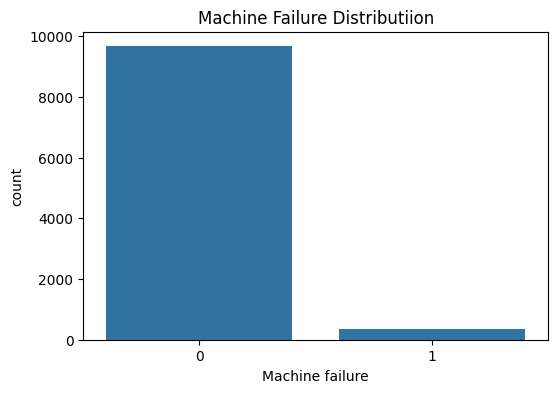

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x='Machine failure',
    data=df
)

plt.title('Machine Failure Distributiion')
plt.show()

In [5]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [6]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [7]:
pd.crosstab(df['Type'], df['Machine failure'])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


# Machine Type Analysis

- L-type machines have the highest failure rate (3.92%).
- M-type machines have a moderate failure rate (2.77%).
- H-type machines have the lowest failure rate (2.09%).
- Machine type appears to influence machine failure.

In [8]:
df.groupby('Machine failure')['Air temperature [K]'].mean()

Machine failure
0    299.973999
1    300.886431
Name: Air temperature [K], dtype: float64

In [9]:
df.groupby('Machine failure')['Process temperature [K]'].mean()

Machine failure
0    309.995570
1    310.290265
Name: Process temperature [K], dtype: float64

In [10]:
df.groupby('Machine failure')['Torque [Nm]'].mean()

Machine failure
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64

In [11]:
df.groupby('Machine failure')['Rotational speed [rpm]'].mean()

Machine failure
0    1540.260014
1    1496.486726
Name: Rotational speed [rpm], dtype: float64

In [12]:
df.groupby('Machine failure')['Tool wear [min]'].mean()

Machine failure
0    106.693717
1    143.781711
Name: Tool wear [min], dtype: float64

# Sensor Feature Analysis

- Tool wear shows a strong relationship with machine failure.
- Failed machines have significantly higher torque values.
- Failed machines operate at lower rotational speeds.
- Air and process temperatures show only small differences between normal and failed machines.
- Tool wear, torque, and rotational speed are expected to be important predictive features.

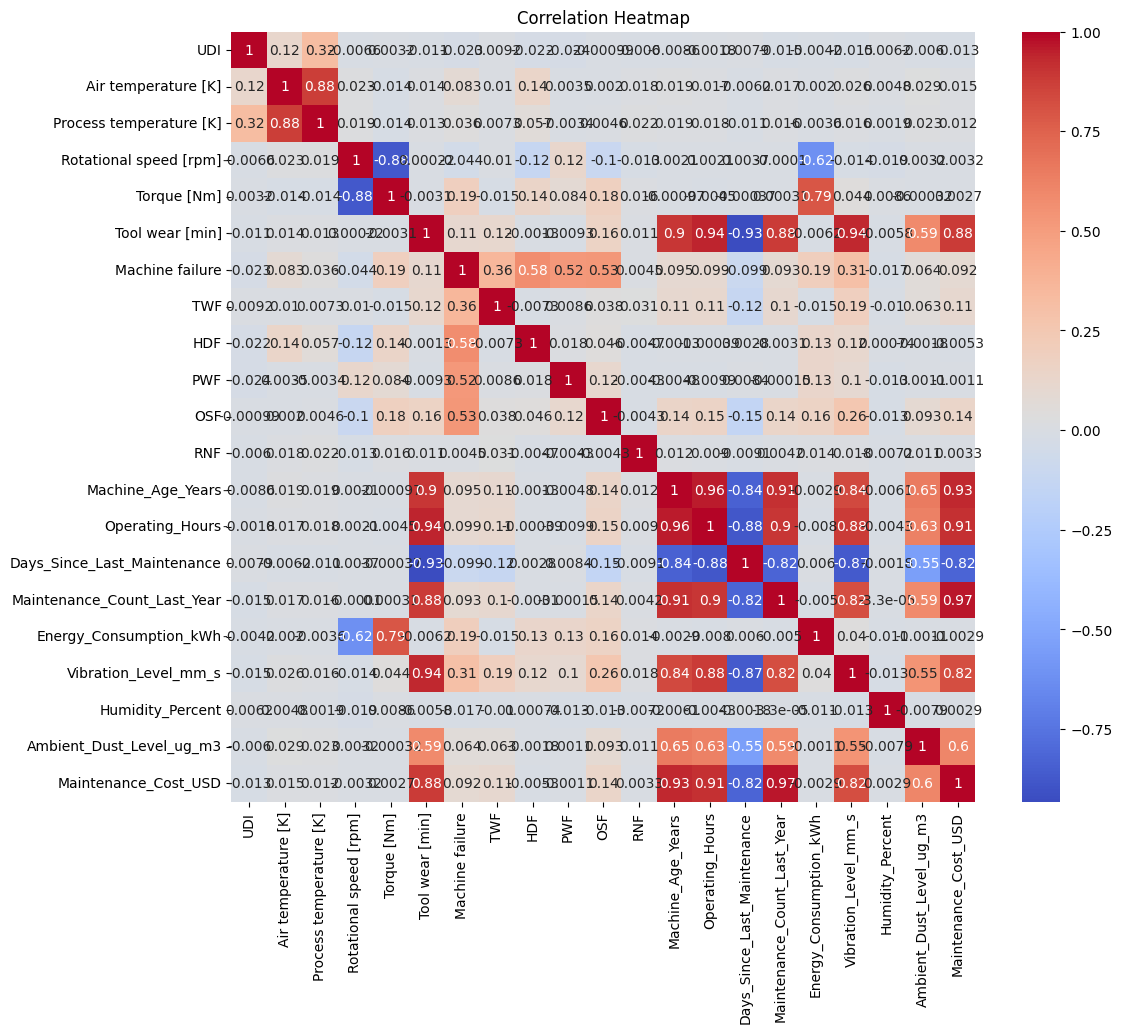

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# EDA Summary

- The merged dataset contains 10,000 machine records and 23 features.
- No missing values were detected after dataset integration.
- The target variable is highly imbalanced.
- L-type machines show the highest failure rate.
- Tool wear is a strong indicator of machine failure.
- Torque is strongly associated with failures.
- Failed machines generally operate at lower rotational speeds.
- The dataset now includes sensor, maintenance, and environmental features for predictive modeling.

In [14]:
new_features = [
    'Machine_Age_Years',
    'Operating_Hours',
    'Days_Since_Last_Maintenance',
    'Maintenance_Count_Last_Year',
    'Energy_Consumption_kWh',
    'Vibration_Level_mm_s',
    'Humidity_Percent',
    'Ambient_Dust_Level_ug_m3',
    'Maintenance_Cost_USD'
]

df[new_features].describe()

,Machine_Age_Years,Operating_Hours,Days_Since_Last_Maintenance,Maintenance_Count_Last_Year,Energy_Consumption_kWh,Vibration_Level_mm_s,Humidity_Percent,Ambient_Dust_Level_ug_m3,Maintenance_Cost_USD
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,8.370900,14935.747500,234.951900,5.53050,58.968306,3.766053,55.155770,36.624850,998.82742
std,3.467468,7017.024349,80.023921,2.69492,8.399636,1.737343,11.864233,10.533679,462.39413
min,1.000000,500.000000,1.000000,0.00000,31.410000,0.500000,30.000000,5.000000,50.00000
25%,6.000000,9172.000000,171.000000,3.00000,53.090000,2.330000,46.900000,29.400000,636.67250
50%,8.000000,14890.000000,237.000000,6.00000,58.530000,3.750000,55.000000,36.600000,996.54000
75%,11.000000,20672.500000,302.000000,8.00000,64.630000,5.100000,63.200000,43.800000,1365.98250
max,15.000000,31848.000000,365.000000,12.00000,97.760000,9.780000,90.000000,74.100000,2206.27000


# IoT and Maintenance Features Overview

- Machine age ranges from 1 to 15 years.
- Operating hours range from 500 to 31,848 hours.
- Days since last maintenance range from 1 to 365 days.
- Maintenance frequency varies from 0 to 12 times per year.
- Environmental features include humidity and dust levels.
- Operational features include energy consumption and vibration levels.
- These features provide additional maintenance and environmental context for failure prediction.

In [15]:
df.groupby("Machine failure")[new_features].mean()

,Machine_Age_Years,Operating_Hours,Days_Since_Last_Maintenance,Maintenance_Count_Last_Year,Energy_Consumption_kWh,Vibration_Level_mm_s,Humidity_Percent,Ambient_Dust_Level_ug_m3,Maintenance_Cost_USD
Machine failure,,,,,,,,,
0,8.309492,14806.269951,236.429252,5.483490,58.662785,3.666561,55.193945,36.499451,990.882456
1,10.120944,18625.666667,192.849558,6.870206,67.675192,6.601416,54.067847,40.198525,1225.247168


# IoT and Maintenance Feature Analysis

- Failed machines are older on average (10.1 vs 8.3 years).
- Failed machines have higher operating hours (18,626 vs 14,806).
- Failed machines show higher energy consumption.
- Failed machines have significantly higher vibration levels.
- Failed machines experience higher maintenance costs.
- Dust levels are slightly higher for failed machines.
- Vibration level, operating hours, machine age, and energy consumption appear to be strong predictors of machine failure.

In [16]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(12,10))
corr['Machine failure'].sort_values(ascending=False)

Machine failure                1.000000
HDF                            0.575800
OSF                            0.531083
PWF                            0.522812
TWF                            0.362904
Vibration_Level_mm_s           0.305727
Energy_Consumption_kWh         0.194184
Torque [Nm]                    0.191321
Tool wear [min]                0.105448
Operating_Hours                0.098509
Machine_Age_Years              0.094547
Maintenance_Count_Last_Year    0.093127
Maintenance_Cost_USD           0.091730
Air temperature [K]            0.082556
Ambient_Dust_Level_ug_m3       0.063554
Process temperature [K]        0.035946
RNF                            0.004516
Humidity_Percent              -0.017178
UDI                           -0.022892
Rotational speed [rpm]        -0.044188
Days_Since_Last_Maintenance   -0.098559
Name: Machine failure, dtype: float64

<Figure size 1200x1000 with 0 Axes>

# Correlation Analysis

- Failure-related indicators (HDF, OSF, PWF, TWF) show the strongest correlations with machine failure.
- Among the newly added IoT features, vibration level has the highest correlation with failure.
- Energy consumption, operating hours, and machine age also show positive relationships with failure.
- Machines with more days since the last maintenance tend to fail less frequently.
- Rotational speed shows a slight negative relationship with failure.
- Vibration level appears to be the most valuable new feature for predictive modeling.

In [17]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Machine_Age_Years', 'Operating_Hours', 'Days_Since_Last_Maintenance',
       'Maintenance_Count_Last_Year', 'Energy_Consumption_kWh',
       'Vibration_Level_mm_s', 'Humidity_Percent', 'Ambient_Dust_Level_ug_m3',
       'Maintenance_Cost_USD'],
      dtype='str')

In [18]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [19]:
df['Type'] = df['Type'].map({
    'L': 0,
    'M': 1,
    'H': 2
})

df['Type'].head()

0    1
1    0
2    0
3    0
4    0
Name: Type, dtype: int64

In [20]:
X = df.drop([
    'Machine failure',
    'UDI',
    'Product ID',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
], axis=1)

y = df['Machine failure']

print(X.shape)
print(y.shape)

(10000, 15)
(10000,)


In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y, test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 15)
(2000, 15)


In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [23]:
print(X_train_smote.shape)
print(X_test.shape)

(15458, 15)
(2000, 15)


In [ ]:
X_train_smote.columns=X_train_smote.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
X_test.columns=X_test.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

#That's because LightGBM doesn't like special characters such as [],/,spaces

In [27]:
from lightgbm import LGBMClassifier
lgbm=LGBMClassifier(random_state=42)
lgbm.fit(X_train_smote,y_train_smote)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20
